In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib
import glob
import re
import pandas as pd
import numpy as np
path = pathlib.Path('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/') #home directory

real = pd.read_csv(str( [i for i in path.glob('real_FLAIR.csv')][0]))
fake = pd.read_csv(str( [i for i in path.glob('fake_T2_to_FLAIR.csv')][0]))
target = pd.read_csv(str( [i for i in path.glob('days2.csv')][0]))

In [ ]:
real['log-sigma-2-0-mm-3D_firstorder_10Percentile']

0     -47.675945
1     -64.296169
2     -52.572416
3     -34.625980
4     -58.433129
         ...    
96    -44.341318
97    -39.262175
98    -54.769653
99    -43.138090
100   -74.896341
Name: log-sigma-2-0-mm-3D_firstorder_10Percentile, Length: 101, dtype: float64

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

## calc correlation

In [ ]:
import numpy as np
corr_matrix = []
for i in range(len(real.T.values)):
  corr_matrix.append(np.corrcoef(real.T.values[i], fake.T.values[i], rowvar=True)[0, 1])

len(corr_matrix)

1118

In [ ]:
corr_matrix = pd.Series(corr_matrix)
corr_matrix.index = real.columns

In [ ]:
sorted_corr_matrix = corr_matrix.sort_values(ascending=False)

In [ ]:
corr_matrix = []
for i in range(np.sum(sorted_corr_matrix<0.9)):
  corr_matrix.append(sorted_corr_matrix.index[i])

In [ ]:
selected_real = pd.DataFrame([])
for i in range(len(corr_matrix)):
  df = pd.DataFrame(real[corr_matrix[i]])
  selected_real = pd.concat([selected_real, df], axis=1)

In [ ]:
selected_fake = pd.DataFrame([])
for i in range(len(corr_matrix)):
  df = pd.DataFrame(fake[corr_matrix[i]])
  selected_fake = pd.concat([selected_fake, df], axis=1)

In [ ]:
len(selected_real.columns)

339

In [ ]:
selected_real.head()

,wavelet-HHH_firstorder_Energy,wavelet-HHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_Energy,wavelet-LHL_firstorder_Energy,wavelet-LHL_firstorder_TotalEnergy,wavelet-HLH_firstorder_Energy,wavelet-HLH_firstorder_TotalEnergy,wavelet-HHL_firstorder_TotalEnergy,wavelet-HHL_firstorder_Energy,...,wavelet-LHH_gldm_LargeDependenceEmphasis,wavelet-HLH_firstorder_Skewness,wavelet-LHL_glrlm_LowGrayLevelRunEmphasis,wavelet-HLH_gldm_LargeDependenceEmphasis,log-sigma-5-0-mm-3D_glcm_Id,wavelet-HHL_glcm_Contrast,wavelet-LHL_gldm_LowGrayLevelEmphasis,wavelet-LHL_glrlm_ShortRunLowGrayLevelEmphasis,log-sigma-4-0-mm-3D_glcm_SumEntropy,wavelet-HHL_firstorder_Variance
0,9.031362e+07,7.225090e+08,7.222176e+08,9.027720e+07,8.886993e+07,7.109595e+08,90140332.2,7.211227e+08,7.342393e+08,9.177992e+07,...,62.305389,-1.480602,0.002125,52.181637,0.447266,36.818759,0.002016,0.002071,5.542578,525.263547
1,1.244088e+08,9.952706e+08,9.983371e+08,1.247921e+08,1.215035e+08,9.720282e+08,125361505.4,1.002892e+09,1.000777e+09,1.250971e+08,...,54.775687,1.110521,0.001819,67.057887,0.439333,30.722976,0.001757,0.001771,5.233928,439.635792
2,5.304650e+08,4.243720e+09,4.251369e+09,5.314212e+08,5.125256e+08,4.100204e+09,531024694.3,4.248198e+09,4.273896e+09,5.342371e+08,...,58.907671,-2.092010,0.001254,73.990835,0.327359,29.407910,0.001215,0.001221,6.233554,412.128541
3,2.122357e+08,1.697886e+09,1.698124e+09,2.122655e+08,2.105667e+08,1.684534e+09,211959763.4,1.695678e+09,1.705844e+09,2.132304e+08,...,66.859992,-0.620070,0.001179,58.586763,0.439967,35.804958,0.001147,0.001147,5.724814,486.469423
4,4.867956e+08,3.894365e+09,3.917020e+09,4.896275e+08,4.785833e+08,3.828666e+09,487525258.0,3.900202e+09,3.925863e+09,4.907329e+08,...,67.236730,3.464678,0.000558,69.899575,0.357732,46.498294,0.000545,0.000549,6.123044,625.010001


## install packages

In [ ]:
!pip install lifelines

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip3 install --upgrade pip

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!pip3 install --upgrade pip setuptools

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
!apt install libpq-dev

Reading package lists... Done
Building dependency tree       
Reading state information... Done
libpq-dev is already the newest version (10.22-0ubuntu0.18.04.1).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [ ]:
!pip install scikit-survival

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## real

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#from sksurv.datasets import load_breast_cancer
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    n_features = coefs.shape[0]
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(
            alpha_min, coef, name + "   ",
            horizontalalignment="right",
            verticalalignment="center"
        )

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

In [ ]:
# 行列の標準化
X = selected_real.iloc[:, 0:].apply(lambda x: (x-x.mean())/x.std(), axis=0)
X.head()

,wavelet-HHH_firstorder_Energy,wavelet-HHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_Energy,wavelet-LHL_firstorder_Energy,wavelet-LHL_firstorder_TotalEnergy,wavelet-HLH_firstorder_Energy,wavelet-HLH_firstorder_TotalEnergy,wavelet-HHL_firstorder_TotalEnergy,wavelet-HHL_firstorder_Energy,...,wavelet-LHH_gldm_LargeDependenceEmphasis,wavelet-HLH_firstorder_Skewness,wavelet-LHL_glrlm_LowGrayLevelRunEmphasis,wavelet-HLH_gldm_LargeDependenceEmphasis,log-sigma-5-0-mm-3D_glcm_Id,wavelet-HHL_glcm_Contrast,wavelet-LHL_gldm_LowGrayLevelEmphasis,wavelet-LHL_glrlm_ShortRunLowGrayLevelEmphasis,log-sigma-4-0-mm-3D_glcm_SumEntropy,wavelet-HHL_firstorder_Variance
0,-1.364374,-1.364374,-1.366637,-1.366637,-1.350847,-1.350847,-1.365243,-1.365243,-1.359084,-1.359084,...,0.358495,-1.060920,0.868361,0.029399,1.072349,0.161494,0.811451,0.896244,-0.708502,0.275311
1,-1.230143,-1.230143,-1.231144,-1.231144,-1.220967,-1.220967,-1.227304,-1.227304,-1.228891,-1.228891,...,0.115393,-0.100407,0.555899,0.487591,0.933142,-0.137794,0.540393,0.576205,-1.506149,-0.049084
2,0.368473,0.368473,0.365133,0.365133,0.335285,0.335285,0.361424,0.361424,0.369906,0.369906,...,0.248797,-1.287565,-0.020867,0.701127,-1.031897,-0.202361,-0.028330,-0.009849,1.077190,-0.153293
3,-0.884375,-0.884375,-0.887755,-0.887755,-0.866499,-0.866499,-0.888153,-0.888153,-0.884492,-0.884492,...,0.505545,-0.741926,-0.097087,0.226678,0.944266,0.111719,-0.100089,-0.088400,-0.237549,0.128342
4,0.196550,0.196550,0.201067,0.201067,0.200196,0.200196,0.191064,0.191064,0.199905,0.199905,...,0.517708,0.772264,-0.730275,0.575115,-0.498889,0.636737,-0.730743,-0.725059,0.791598,0.653194


In [ ]:
target['day']

0      558
1      322
2      630
3      370
4       86
      ... 
96     153
97       7
98     282
99     235
100    237
Name: day, Length: 101, dtype: int64

In [ ]:
arr = []
for i in range(len(target.values)):
  arr.append(tuple(target.values[i]))

In [ ]:
Y = np.array(arr,([('e.tdm', '?'), ('t.tdm', '<f8')]))
X.shape,Y.shape

((101, 339), (101,))

In [ ]:
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_lasso.fit(X, Y)

CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0)

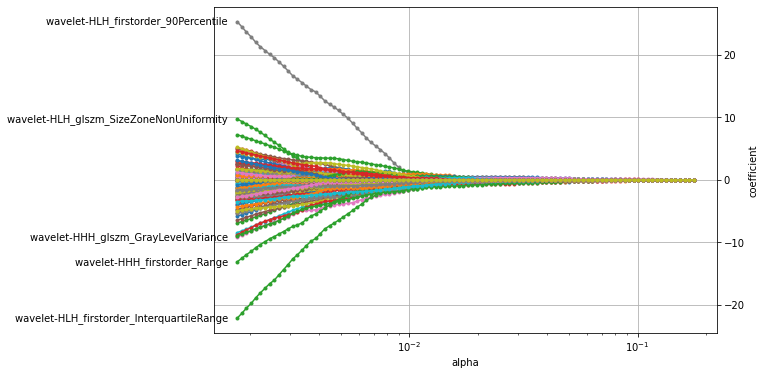

In [ ]:
coefficients_lasso = pd.DataFrame(
    cox_lasso.coef_,
    index=X.columns,
    columns=np.round(cox_lasso.alphas_, 5)
)

plot_coefficients(coefficients_lasso, n_highlight=5)

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

coxnet_pipe = make_pipeline(
    StandardScaler(),
    CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100)
)
warnings.simplefilter("ignore", ConvergenceWarning)
coxnet_pipe.fit(X, Y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('coxnetsurvivalanalysis',
                 CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9,
                                        max_iter=100))])

In [ ]:
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
cv = KFold(n_splits=10, shuffle=True, random_state=0)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in estimated_alphas]},
    cv=cv,
    error_score=0.5,
    n_jobs=4).fit(X,Y)

cv_results = pd.DataFrame(gcv.cv_results_)

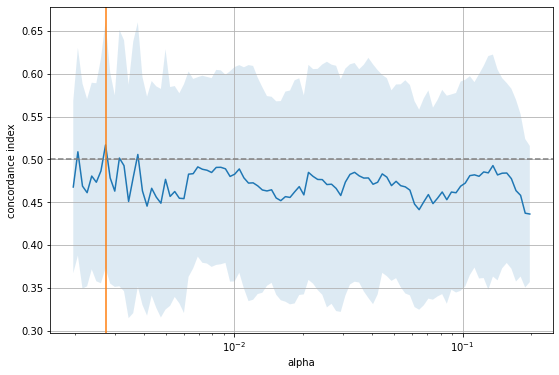

In [ ]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

Number of non-zero coefficients: 198


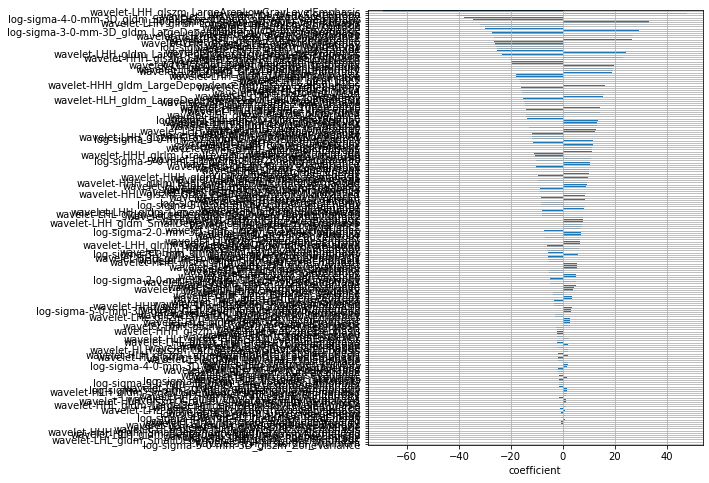

In [ ]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(
    best_model.coef_,
    index=X.columns,
    columns=["coefficient"]
)

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print("Number of non-zero coefficients: {}".format(non_zero))

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

In [ ]:
non_zero_coefs

,coefficient
wavelet-LHH_glrlm_GrayLevelNonUniformity,19.140591
wavelet-HLH_glrlm_GrayLevelNonUniformity,1.375049
log-sigma-5-0-mm-3D_glrlm_RunLengthNonUniformity,1.536401
wavelet-LHL_firstorder_RootMeanSquared,-3.516337
wavelet-HLL_glcm_ClusterProminence,-20.386974
...,...
wavelet-HLH_gldm_LargeDependenceEmphasis,9.139878
wavelet-LHL_gldm_LowGrayLevelEmphasis,-1.983280
wavelet-LHL_glrlm_ShortRunLowGrayLevelEmphasis,-1.019670
log-sigma-4-0-mm-3D_glcm_SumEntropy,-34.515231


In [ ]:
non_zero_coefs.T.columns[0]

'wavelet-LHH_glrlm_GrayLevelNonUniformity'

In [ ]:
non_zero_coefs.T.values

array([[ 1.91405908e+01,  1.37504880e+00,  1.53640106e+00,
        -3.51633703e+00, -2.03869736e+01,  1.05062251e+01,
         3.15547718e+00, -1.80206595e+01, -1.67680046e+00,
         1.43588279e+01,  7.70931056e+00,  7.51838175e+00,
        -1.86023831e+00,  6.05336670e-01,  2.09558386e+00,
        -8.88715254e+00,  3.50474516e+00, -5.26230277e+00,
        -1.40536842e+01,  4.12514764e+00, -8.72135499e-01,
        -8.06531989e-01, -1.40832921e+01, -3.73435208e+00,
         1.85007767e+00,  6.59007320e+00, -1.45590316e+01,
        -1.50126773e+01,  6.03996666e+00,  1.25825702e+01,
        -8.06561028e+00,  5.20881202e+00,  1.82309172e+00,
        -2.26282134e+00,  3.68086431e+00,  1.13256855e+01,
        -5.23460073e+00, -1.44151760e+01,  2.30433253e+01,
         8.61713579e+00,  1.06189933e+01,  8.42619408e+00,
         8.51906238e+00, -1.56407096e+00,  9.56505322e+00,
        -2.59699795e+00, -1.78887624e+01,  4.91735322e+00,
         1.53210642e+00,  5.33019249e+00, -4.91787950e+0

In [ ]:
lasso_real = pd.DataFrame([])
for i in range(len(non_zero_coefs)):
  df = pd.DataFrame(X[non_zero_coefs.T.columns[i]])
  df = df.iloc[:, 0:].apply(lambda x: x*non_zero_coefs.T.values[0][i], axis=0)

  lasso_real = pd.concat([lasso_real, df], axis=1)

In [ ]:
lasso_real

,wavelet-LHH_glrlm_GrayLevelNonUniformity,wavelet-HLH_glrlm_GrayLevelNonUniformity,log-sigma-5-0-mm-3D_glrlm_RunLengthNonUniformity,wavelet-LHL_firstorder_RootMeanSquared,wavelet-HLL_glcm_ClusterProminence,wavelet-LHH_glcm_InverseVariance,wavelet-LHL_glcm_ClusterProminence,wavelet-LHH_glcm_ClusterProminence,wavelet-HHH_glcm_InverseVariance,wavelet-LHH_firstorder_10Percentile,...,wavelet-HLH_firstorder_Mean,log-sigma-4-0-mm-3D_gldm_SmallDependenceLowGrayLevelEmphasis,wavelet-LHH_glrlm_LongRunLowGrayLevelEmphasis,wavelet-HLH_firstorder_Skewness,wavelet-LHL_glrlm_LowGrayLevelRunEmphasis,wavelet-HLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LowGrayLevelEmphasis,wavelet-LHL_glrlm_ShortRunLowGrayLevelEmphasis,log-sigma-4-0-mm-3D_glcm_SumEntropy,wavelet-HHL_firstorder_Variance
0,-18.433099,-1.389507,-2.115486,-1.071016,1.823468,9.473075,-1.526818,6.381515,-0.711554,14.541389,...,2.479586,-52.931066,20.440797,-1.756988,-1.172060,0.268701,-1.609334,-0.913873,24.454105,1.951361
1,-19.673546,-1.327847,-1.956336,0.090939,-9.424864,7.985840,-0.835138,6.317699,-1.288366,8.011955,...,-2.786146,-22.454666,-4.404943,-0.166284,-0.750318,4.456518,-1.071750,-0.587539,51.985076,-0.347896
2,14.828994,1.266433,0.814720,1.496916,3.992174,8.403640,-1.043833,6.385138,-1.422592,9.158056,...,0.982801,9.823508,1.212111,-2.132334,0.028164,6.408214,0.056187,0.010042,-37.179470,-1.086515
3,-5.898685,-0.612278,-1.374647,-2.034332,3.538221,9.897195,-0.653347,6.399808,-1.469301,13.250549,...,2.337443,2.338576,-0.499946,-1.228703,0.131042,2.071810,0.198504,0.090139,8.199057,0.909670
4,5.166384,0.637836,0.359366,-0.800095,2.878543,5.334566,1.693487,3.116775,-1.101672,6.245309,...,0.954985,27.866661,-17.928599,1.278944,0.985680,5.256482,1.449268,0.739321,-27.322180,4.629731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,50.723999,3.580115,3.178138,-0.759295,3.229693,9.002999,-1.522759,5.940243,-1.112790,10.425884,...,0.874990,27.892818,-11.488116,-1.411014,0.583265,11.257114,0.839498,0.461612,-5.984699,-4.297661
97,14.534902,0.913614,-0.115788,-3.380701,4.405603,10.040802,-1.294202,6.361220,-1.587386,11.830435,...,1.567046,16.560170,10.510323,-0.516606,0.646383,3.716054,0.947115,0.488769,36.306390,-3.711436
98,-12.382156,-0.615200,-1.271386,-0.918679,4.307201,4.256872,-0.360694,6.084741,-1.219372,7.696937,...,3.857346,-40.766653,-14.597797,-0.277551,0.518203,10.774904,0.802489,0.384563,13.365381,-6.416922
99,1.087085,-0.071696,-0.740025,-0.735829,4.262929,9.676974,-1.551678,4.345933,-1.339449,11.131348,...,0.776755,-26.991127,-8.878173,0.412286,0.278703,1.182163,0.405207,0.210645,17.880276,-6.049585


In [ ]:
new_lasso_real = []
for i in range(len(lasso_real.columns)):
  if i == 0:
    new_lasso_real = lasso_real[lasso_real.columns[0]]
  elif i > 0:
    new_lasso_real = new_lasso_real + lasso_real[lasso_real.columns[i]]

In [ ]:
new_lasso_real

0       -1.360674
1        0.673171
2       -1.074099
3       -0.832717
4       74.254457
          ...    
96      19.305550
97     -23.332145
98    -123.485549
99    -128.337430
100    -69.667029
Length: 101, dtype: float64

In [ ]:
new_lasso_real = pd.DataFrame(new_lasso_real, columns=['rad_score'])
new_lasso_real.head()

,rad_score
0,-1.360674
1,0.673171
2,-1.074099
3,-0.832717
4,74.254457


In [ ]:
arr = []
for i in range(len(target.values)):
  arr.append(tuple(target.values[i]))

In [ ]:
np.array(arr)

array([[   1,  558],
       [   1,  322],
       [   1,  630],
       [   1,  370],
       [   1,   86],
       [   1,  430],
       [   1,  110],
       [   1,  209],
       [   1,  448],
       [   1,  199],
       [   1,  291],
       [   1,  600],
       [   1,  804],
       [   0,  873],
       [   0,  762],
       [   1,  634],
       [   1, 1561],
       [   1,  268],
       [   0, 1757],
       [   1,  822],
       [   1,  355],
       [   1, 1489],
       [   1,   82],
       [   1,  187],
       [   1,  394],
       [   1,  812],
       [   1,  737],
       [   1,  362],
       [   1,   67],
       [   1,   71],
       [   1,  262],
       [   1,  424],
       [   1,  329],
       [   1,  104],
       [   1, 1731],
       [   0, 1562],
       [   1,  127],
       [   1,  616],
       [   1,  111],
       [   0, 1228],
       [   0, 1126],
       [   1,  828],
       [   0,  866],
       [   1,  317],
       [   0,  557],
       [   1,  405],
       [   1,  621],
       [   0,

In [ ]:
new_Y = pd.DataFrame(np.array(arr),columns=["arrest","day"])
new_Y

,arrest,day
0,1,558
1,1,322
2,1,630
3,1,370
4,1,86
...,...,...
96,1,153
97,0,7
98,0,282
99,0,235


In [ ]:
real_rad_score = new_lasso_real.join(new_Y)

## fake

In [ ]:
X = selected_fake

In [ ]:
# 行列の標準化
X = selected_fake.iloc[:, 0:].apply(lambda x: (x-x.mean())/x.std(), axis=0)
X.head()

,wavelet-HHH_firstorder_Energy,wavelet-HHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_TotalEnergy,wavelet-LHH_firstorder_Energy,wavelet-LHL_firstorder_Energy,wavelet-LHL_firstorder_TotalEnergy,wavelet-HLH_firstorder_Energy,wavelet-HLH_firstorder_TotalEnergy,wavelet-HHL_firstorder_TotalEnergy,wavelet-HHL_firstorder_Energy,...,wavelet-LHH_gldm_LargeDependenceEmphasis,wavelet-HLH_firstorder_Skewness,wavelet-LHL_glrlm_LowGrayLevelRunEmphasis,wavelet-HLH_gldm_LargeDependenceEmphasis,log-sigma-5-0-mm-3D_glcm_Id,wavelet-HHL_glcm_Contrast,wavelet-LHL_gldm_LowGrayLevelEmphasis,wavelet-LHL_glrlm_ShortRunLowGrayLevelEmphasis,log-sigma-4-0-mm-3D_glcm_SumEntropy,wavelet-HHL_firstorder_Variance
0,-1.364391,-1.364391,-1.367092,-1.367092,-1.353542,-1.353542,-1.365278,-1.365278,-1.358948,-1.358948,...,-0.254672,-0.539077,1.616166,-0.735176,-0.633642,1.412735,1.631268,1.691708,-0.080542,1.510986
1,-1.230272,-1.230272,-1.231437,-1.231437,-1.220361,-1.220361,-1.228367,-1.228367,-1.230472,-1.230472,...,0.245996,-0.022446,0.483198,0.658965,0.871859,-0.266710,0.465409,0.496574,-1.453424,-0.162396
2,0.368739,0.368739,0.365622,0.365622,0.335684,0.335684,0.362364,0.362364,0.371513,0.371513,...,0.113537,-1.216735,-0.150573,0.672929,-1.049595,-0.136014,-0.152065,-0.143543,1.119027,-0.089740
3,-0.884507,-0.884507,-0.887813,-0.887813,-0.865403,-0.865403,-0.888802,-0.888802,-0.885065,-0.885065,...,0.352153,-0.699168,-0.183122,0.114725,0.944144,0.156619,-0.186613,-0.174558,-0.237632,0.157706
4,0.196736,0.196736,0.201157,0.201157,0.198844,0.198844,0.192164,0.192164,0.200175,0.200175,...,0.487863,0.911323,-0.694032,0.510302,-0.511727,0.532326,-0.693934,-0.686730,0.743558,0.550621


In [ ]:
arr = []
for i in range(len(target.values)):
  arr.append(tuple(target.values[i]))

In [ ]:
Y = np.array(arr,([('e.tdm', '?'), ('t.tdm', '<f8')]))

In [ ]:
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
cox_lasso.fit(X, Y)

CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=1.0)

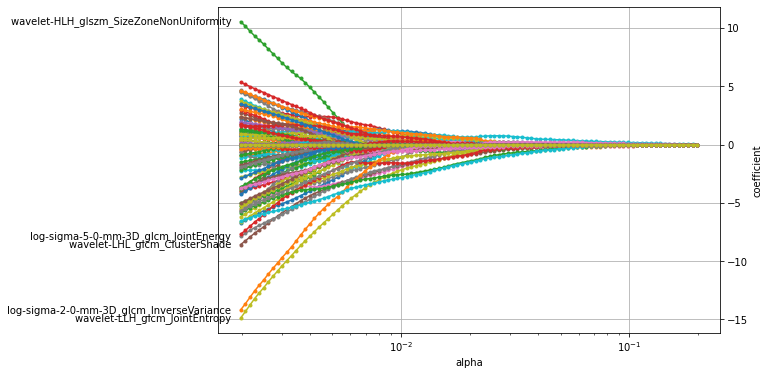

In [ ]:
coefficients_lasso = pd.DataFrame(
    cox_lasso.coef_,
    index=X.columns,
    columns=np.round(cox_lasso.alphas_, 5)
)

plot_coefficients(coefficients_lasso, n_highlight=5)

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

coxnet_pipe = make_pipeline(
    StandardScaler(),
    CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100)
)
warnings.simplefilter("ignore", ConvergenceWarning)
coxnet_pipe.fit(X, Y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('coxnetsurvivalanalysis',
                 CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, l1_ratio=0.9,
                                        max_iter=100))])

In [ ]:
estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
cv = KFold(n_splits=10, shuffle=True, random_state=0)
gcv = GridSearchCV(
    make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
    param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in estimated_alphas]},
    cv=cv,
    error_score=0.5,
    n_jobs=4).fit(X,Y)

cv_results = pd.DataFrame(gcv.cv_results_)

/usr/local/lib/python3.8/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
4 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to 0.5.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.8/dist-packages/sklearn/pipeline.py", line 382, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/usr/local/lib/python3.8/dist-packages/sksurv/linear_model/coxnet.py", line 249, in fit
    coef, alphas, deviance_ratio, n_iter = call_fit_coxnet(
  File "sksurv/

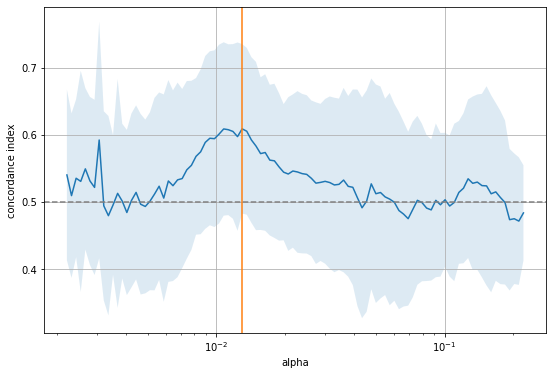

In [ ]:
alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
mean = cv_results.mean_test_score
std = cv_results.std_test_score

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alphas, mean)
ax.fill_between(alphas, mean - std, mean + std, alpha=.15)
ax.set_xscale("log")
ax.set_ylabel("concordance index")
ax.set_xlabel("alpha")
ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
ax.axhline(0.5, color="grey", linestyle="--")
ax.grid(True)

Number of non-zero coefficients: 69


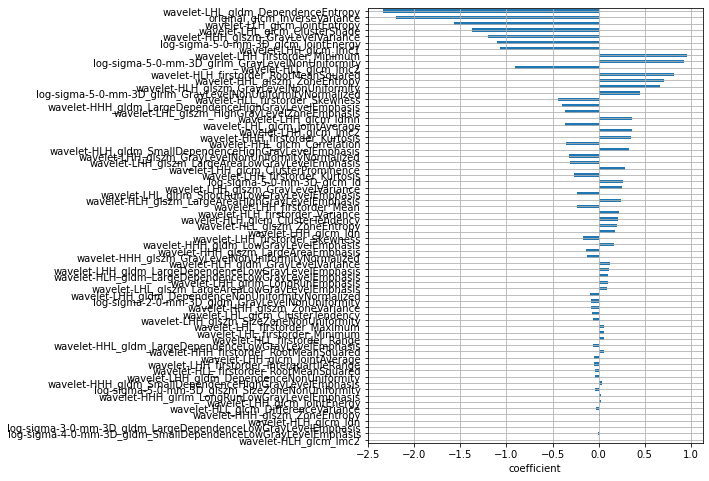

In [ ]:
best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
best_coefs = pd.DataFrame(
    best_model.coef_,
    index=X.columns,
    columns=["coefficient"]
)

non_zero = np.sum(best_coefs.iloc[:, 0] != 0)
print("Number of non-zero coefficients: {}".format(non_zero))

non_zero_coefs = best_coefs.query("coefficient != 0")
coef_order = non_zero_coefs.abs().sort_values("coefficient").index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
ax.set_xlabel("coefficient")
ax.grid(True)

In [ ]:
non_zero_coefs

,coefficient
wavelet-LHH_glcm_ClusterProminence,0.289547
wavelet-LHH_firstorder_Mean,-0.235055
wavelet-HLL_glcm_DifferenceVariance,-0.029246
wavelet-HHH_firstorder_RootMeanSquared,0.055083
wavelet-LHH_gldm_DependenceNonUniformityNormalized,-0.090573
...,...
wavelet-HHH_gldm_SmallDependenceHighGrayLevelEmphasis,0.037449
wavelet-LHH_glcm_Idmn,0.363074
log-sigma-4-0-mm-3D_gldm_SmallDependenceLowGrayLevelEmphasis,-0.006811
log-sigma-5-0-mm-3D_glcm_Id,0.262678


In [ ]:
non_zero_coefs.T.values

array([[ 2.89547179e-01, -2.35055480e-01, -2.92460643e-02,
         5.50829711e-02, -9.05731597e-02,  3.27694124e-01,
        -5.87554009e-02, -8.33549221e-02,  2.07809722e-01,
        -1.39055024e-01, -4.32671039e-02,  2.24482113e-01,
        -6.50731483e-02,  1.19863778e-01,  9.12781420e-02,
        -3.56098857e-02, -1.19903876e+00, -3.19305683e-01,
        -1.37564547e+00, -3.50773711e-01, -4.87573011e-02,
        -2.69359575e-01, -1.68251204e-01, -3.86168995e-02,
         3.55681437e-01,  6.01393591e-02, -3.67094157e-01,
        -3.60482733e-01,  5.91348153e-02, -2.98753590e-05,
        -1.29409538e-01, -4.00479282e-01,  2.53670606e-01,
         3.50878882e-01,  1.73314814e-01,  2.96965201e-02,
        -8.35160063e-02, -7.30846120e-02, -3.11346842e-01,
         9.61983469e-01, -5.30551134e-02, -4.39726252e-01,
        -1.56403623e+00,  1.39974340e-02,  1.80227114e-02,
         1.07717990e-01, -1.10720620e+00, -9.11561966e-01,
         6.67005236e-01,  1.04180016e-01,  2.01415047e-0

In [ ]:
lasso_fake = pd.DataFrame([])
for i in range(len(non_zero_coefs)):
  df = pd.DataFrame(X[non_zero_coefs.T.columns[i]])
  df = df.iloc[:, 0:].apply(lambda x: x*non_zero_coefs.T.values[0][i], axis=0)

  lasso_fake = pd.concat([lasso_fake, df], axis=1)

In [ ]:
new_lasso_fake = []
for i in range(len(lasso_fake.columns)):
  if i == 0:
    new_lasso_fake = lasso_fake[lasso_fake.columns[0]]
  elif i > 0:
    new_lasso_fake = new_lasso_fake + lasso_fake[lasso_fake.columns[i]]

In [ ]:
new_lasso_fake = pd.DataFrame(new_lasso_fake, columns=['rad_score'])
new_lasso_fake.head()

,rad_score
0,0.286456
1,1.487208
2,0.145626
3,-0.928691
4,0.177154


In [ ]:
arr = []
for i in range(len(target.values)):
  arr.append(tuple(target.values[i]))

In [ ]:
np.array(arr)

array([[   1,  558],
       [   1,  322],
       [   1,  630],
       [   1,  370],
       [   1,   86],
       [   1,  430],
       [   1,  110],
       [   1,  209],
       [   1,  448],
       [   1,  199],
       [   1,  291],
       [   1,  600],
       [   1,  804],
       [   0,  873],
       [   0,  762],
       [   1,  634],
       [   1, 1561],
       [   1,  268],
       [   0, 1757],
       [   1,  822],
       [   1,  355],
       [   1, 1489],
       [   1,   82],
       [   1,  187],
       [   1,  394],
       [   1,  812],
       [   1,  737],
       [   1,  362],
       [   1,   67],
       [   1,   71],
       [   1,  262],
       [   1,  424],
       [   1,  329],
       [   1,  104],
       [   1, 1731],
       [   0, 1562],
       [   1,  127],
       [   1,  616],
       [   1,  111],
       [   0, 1228],
       [   0, 1126],
       [   1,  828],
       [   0,  866],
       [   1,  317],
       [   0,  557],
       [   1,  405],
       [   1,  621],
       [   0,

In [ ]:
new_Y = pd.DataFrame(np.array(arr),columns=["arrest","day"])
new_Y

,arrest,day
0,1,558
1,1,322
2,1,630
3,1,370
4,1,86
...,...,...
96,1,153
97,0,7
98,0,282
99,0,235


In [ ]:
fake_rad_score = new_lasso_fake.join(new_Y)

In [ ]:
fake_rad_score

,rad_score,arrest,day
0,0.286456,1,558
1,1.487208,1,322
2,0.145626,1,630
3,-0.928691,1,370
4,0.177154,1,86
...,...,...,...
96,2.167067,1,153
97,1.368300,0,7
98,-5.040178,0,282
99,1.327477,0,235


## kaplanmeir & Log rank test

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.datasets import load_gbsg2 # test data of breast cancer with hormone treatment
from lifelines import CoxPHFitter # Cox model
%matplotlib inline

In [ ]:
kmfF = KaplanMeierFitter()
Tf = real_rad_score['day']
Ef = real_rad_score['arrest']

kmfF.fit(Tf, event_observed=Ef)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 101 total observations, 25 right-censored observations>

Text(0.5, 1.0, 'Over All Survive')

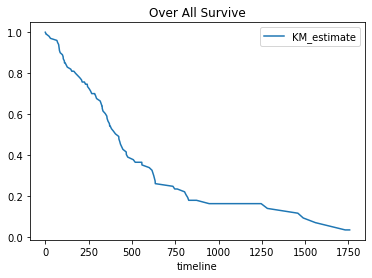

In [ ]:
from matplotlib import pyplot as plt

kmfF.survival_function_.plot()
plt.title('Over All Survive')

In [ ]:
#rad_score median
real_median = np.median(real_rad_score["rad_score"].values)
fake_median = np.median(fake_rad_score["rad_score"].values)

In [ ]:
#変数名がおかしい。直したい。。。
real_good = real_rad_score.query('rad_score > @real_median')
real_poor = real_rad_score.query('rad_score < @real_median')
fake_good = fake_rad_score.query('rad_score > @fake_median')
fake_poor = fake_rad_score.query('rad_score < @fake_median')

In [ ]:
len(fake_good)

50

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          67.94 <0.005     52.40

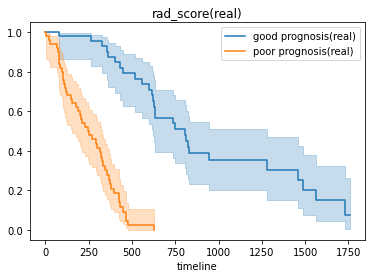

In [ ]:
import numpy as np
from lifelines.statistics import logrank_test
kmf = KaplanMeierFitter()

Tr1 = real_good['day']
Er1 = real_good['arrest']
Tr2 = real_poor['day']
Er2 = real_poor['arrest']
Tf1 = fake_good['day']
Ef1 = fake_good['arrest']
Tf2 = fake_poor['day']
Ef2 = fake_poor['arrest']

ax = plt.subplot(111)
t = np.linspace(0, 50, 51)
#ラベルがまちがっている。
kmf.fit(Tr2, event_observed=Er2, label="good prognosis(real)").plot(ax=ax)
kmf.fit(Tr1, event_observed=Er1, label="poor prognosis(real)").plot(ax=ax)

plt.title("rad_score(real)")
results = logrank_test(Tr1, Tr2, Er1, Er2, alpha=.99)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          85.67 <0.005     65.35

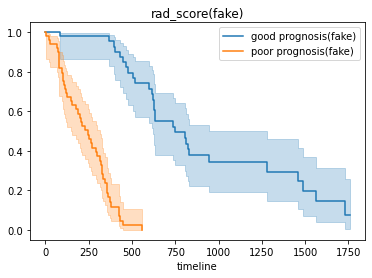

In [ ]:
ax = plt.subplot(111)
t = np.linspace(0, 50, 51)
kmf.fit(Tf2, event_observed=Ef2, label="good prognosis(fake)").plot(ax=ax)
kmf.fit(Tf1, event_observed=Ef1, label="poor prognosis(fake)").plot(ax=ax)

plt.title("rad_score(fake)")
results = logrank_test(Tf1, Tf2, Ef1, Ef2, alpha=.99)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.00 0.99      0.02

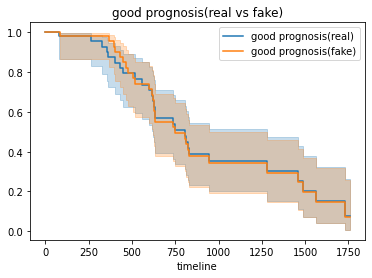

In [ ]:
ax = plt.subplot(111)
t = np.linspace(0, 50, 51)
kmf.fit(Tr2, event_observed=Er2, label="good prognosis(real)").plot(ax=ax)
kmf.fit(Tf2, event_observed=Ef2, label="good prognosis(fake)").plot(ax=ax)

plt.title("good prognosis(real vs fake)")
results = logrank_test(Tr2, Tf2, Er2, Ef2, alpha=.99)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.86 0.35      1.50

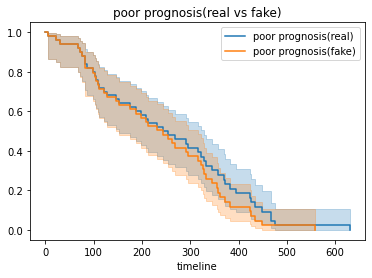

In [ ]:
ax = plt.subplot(111)
t = np.linspace(0, 50, 51)
kmf.fit(Tr1, event_observed=Er1, label="poor prognosis(real)").plot(ax=ax)
kmf.fit(Tf1, event_observed=Ef1, label="poor prognosis(fake)").plot(ax=ax)

plt.title("poor prognosis(real vs fake)")
results = logrank_test(Tr1, Tf1, Er1, Ef1, alpha=.99)
results.print_summary()

## detail check

In [ ]:
len(real_rad_score)

101

In [ ]:
name = []
for i in range(len(real_rad_score)):
  name.append("case_"+str(i))

In [ ]:
name = pd.DataFrame(np.array(name),columns=["name"])

In [ ]:
real_rad_score = real_rad_score.join(name)

In [ ]:
real_rad_score.values

array([[-1.3606740529760941, 1, 558, 'case_0'],
       [0.6731713433787943, 1, 322, 'case_1'],
       [-1.074098657410651, 1, 630, 'case_2'],
       [-0.8327165258459892, 1, 370, 'case_3'],
       [74.25445674132258, 1, 86, 'case_4'],
       [-1.4618312618635128, 1, 430, 'case_5'],
       [166.1250418151549, 1, 110, 'case_6'],
       [87.7711361089095, 1, 209, 'case_7'],
       [-0.4184078973638239, 1, 448, 'case_8'],
       [92.64663920857048, 1, 199, 'case_9'],
       [3.069040087893643, 1, 291, 'case_10'],
       [-3.697982953442536, 1, 600, 'case_11'],
       [-2.1143809094142716, 1, 804, 'case_12'],
       [-25.7039571244786, 0, 873, 'case_13'],
       [-10.996334863078813, 0, 762, 'case_14'],
       [-2.841189871578687, 1, 634, 'case_15'],
       [-3.9761391096816987, 1, 1561, 'case_16'],
       [9.518462149347748, 1, 268, 'case_17'],
       [-8.450112650043298, 0, 1757, 'case_18'],
       [-3.151301462934385, 1, 822, 'case_19'],
       [-2.4764147919030632, 1, 355, 'case_20'],
 

In [ ]:
fake_rad_score = fake_rad_score.join(name)

In [ ]:
fake_rad_score.values

array([[0.28645611421545447, 1, 558, 'case_0'],
       [1.487208135978554, 1, 322, 'case_1'],
       [0.14562623587760687, 1, 630, 'case_2'],
       [-0.9286914584784061, 1, 370, 'case_3'],
       [0.1771544853093819, 1, 86, 'case_4'],
       [-0.31904014519313556, 1, 430, 'case_5'],
       [2.34865612330293, 1, 110, 'case_6'],
       [1.2084851583840748, 1, 209, 'case_7'],
       [0.8624347856417338, 1, 448, 'case_8'],
       [1.5078229194658044, 1, 199, 'case_9'],
       [1.527431301158168, 1, 291, 'case_10'],
       [-0.4189689877170342, 1, 600, 'case_11'],
       [-1.2605763122891158, 1, 804, 'case_12'],
       [-3.5374563049286007, 0, 873, 'case_13'],
       [-1.0406252556149354, 0, 762, 'case_14'],
       [-0.7916731999494926, 1, 634, 'case_15'],
       [-2.1791079162908713, 1, 1561, 'case_16'],
       [2.2913637321894247, 1, 268, 'case_17'],
       [-3.2331329596907725, 0, 1757, 'case_18'],
       [-1.2893794759119324, 1, 822, 'case_19'],
       [0.9868850765044559, 1, 355, 'cas

In [ ]:
real_good = real_rad_score.query('rad_score > @real_median')
real_poor = real_rad_score.query('rad_score < @real_median')
fake_good = fake_rad_score.query('rad_score > @fake_median')
fake_poor = fake_rad_score.query('rad_score < @fake_median')

In [ ]:
real_good

,rad_score,arrest,day,name
1,0.673171,1,322,case_1
2,-1.074099,1,630,case_2
3,-0.832717,1,370,case_3
4,74.254457,1,86,case_4
6,166.125042,1,110,case_6
7,87.771136,1,209,case_7
8,-0.418408,1,448,case_8
9,92.646639,1,199,case_9
10,3.069040,1,291,case_10
17,9.518462,1,268,case_17


In [ ]:
fake_poor.values

array([[0.14562623587760687, 1, 630, 'case_2'],
       [-0.9286914584784061, 1, 370, 'case_3'],
       [0.1771544853093819, 1, 86, 'case_4'],
       [-0.31904014519313556, 1, 430, 'case_5'],
       [-0.4189689877170342, 1, 600, 'case_11'],
       [-1.2605763122891158, 1, 804, 'case_12'],
       [-3.5374563049286007, 0, 873, 'case_13'],
       [-1.0406252556149354, 0, 762, 'case_14'],
       [-0.7916731999494926, 1, 634, 'case_15'],
       [-2.1791079162908713, 1, 1561, 'case_16'],
       [-3.2331329596907725, 0, 1757, 'case_18'],
       [-1.2893794759119324, 1, 822, 'case_19'],
       [-2.300592765867362, 1, 1489, 'case_21'],
       [-0.944090325706645, 1, 394, 'case_24'],
       [-0.5835337178617311, 1, 812, 'case_25'],
       [-0.059790049068886186, 1, 737, 'case_26'],
       [-3.327687959174603, 1, 1731, 'case_34'],
       [-3.225715327216455, 0, 1562, 'case_35'],
       [-1.1723978658027483, 1, 616, 'case_37'],
       [-1.337008711197132, 0, 1228, 'case_39'],
       [-2.12881882457

In [ ]:
real_good_prog =  real_good['name'].values
real_good_prog

array(['case_1', 'case_2', 'case_3', 'case_4', 'case_6', 'case_7',
       'case_8', 'case_9', 'case_10', 'case_17', 'case_22', 'case_23',
       'case_24', 'case_28', 'case_29', 'case_31', 'case_32', 'case_33',
       'case_36', 'case_38', 'case_43', 'case_48', 'case_50', 'case_52',
       'case_53', 'case_58', 'case_59', 'case_60', 'case_61', 'case_62',
       'case_63', 'case_64', 'case_69', 'case_71', 'case_72', 'case_73',
       'case_74', 'case_76', 'case_77', 'case_79', 'case_80', 'case_81',
       'case_82', 'case_83', 'case_88', 'case_89', 'case_92', 'case_94',
       'case_95', 'case_96'], dtype=object)

In [ ]:
fake_good_prog = fake_good['name'].values
fake_good_prog

array(['case_0', 'case_1', 'case_6', 'case_7', 'case_8', 'case_9',
       'case_10', 'case_17', 'case_20', 'case_22', 'case_23', 'case_27',
       'case_28', 'case_29', 'case_30', 'case_31', 'case_32', 'case_33',
       'case_36', 'case_38', 'case_43', 'case_48', 'case_52', 'case_58',
       'case_60', 'case_62', 'case_63', 'case_64', 'case_66', 'case_69',
       'case_71', 'case_72', 'case_74', 'case_76', 'case_77', 'case_78',
       'case_79', 'case_80', 'case_81', 'case_82', 'case_83', 'case_88',
       'case_89', 'case_91', 'case_92', 'case_94', 'case_95', 'case_96',
       'case_97', 'case_99'], dtype=object)

In [ ]:
diff_good_prog = []
for i in range(len(real_good_prog)):
  if real_good_prog[i] != fake_good_prog[i]:
    diff_good_prog.append()

TypeError: ignored

In [ ]:
real_rad_score.to_csv('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/real_T2_to_FLAIR_rad_score.csv')